# S8-1 MBSの仕組みとプリペイメントモデル

## 学習目標

- パススルー証券（pass-through security）のキャッシュフローを、利息・予定元本・
  期限前償還の3成分に分けて構成できる
- CPR・SMM・PSA の三者を式で結び付け、PSA ramp（age30 で 6% 到達）を数値で示せる
- 期限前償還の動機を借換・住替・デフォルトに分解し、金利インセンティブとバーンアウトが
  S字カーブ（S-curve）をどう歪めるかを説明できる
- PSA と簡易計量プリペイメントモデル（金利差依存のロジスティック）を自作し、
  `bondlab.mbs` の `psa_cpr` / `cpr_to_smm` / `mbs_cashflows` /
  `weighted_average_life` と一致することを確認できる
- 金利が $\pm$100bp 動いたときの MBS 価格を計算し、ネガティブコンベクシティ
  （negative convexity）を数値で確認できる

## 実務での位置づけ（ファンドはどう稼ぐか）

MBS はエージェンシー保証で信用リスクがほぼ無いぶん、値付けの主戦場が「プリペイメント（期限前償還）をどう読むか」に集約されます。米系運用会社の MBS デスクや PIMCO・BlackRock のようなコア債券ファンドは、TBA（to-be-announced）市場でクーポン別プールを日々売買し、国債やスワップに対する相対価値（RV）と、保有していれば得られるキャリーの両方でリターンを積み上げます。ここで自作したパススルーの3成分分解と PSA/SMM の計算は、その値付けの一番下の層にあたります。プールごとに WAC・WAM・ローンエイジ・地域・ローンサイズが異なり、これらが将来 CPR を左右するため、デスクは同じクーポンでも「速く返ってきそうなプール」と「遅いプール」を区別して仕入れ値を変えます。この銘柄選別（プールペイアップ）が超過リターンの源泉になります。

MBS が国債と決定的に違うのは、借り手が「金利が下がったら借り換える」というコール（繰上返済）オプションを握っている点です。投資家はそのオプションを売っている側なので、金利が下がると期限前償還が加速して高いクーポンを早く失い（コールされ）、金利が上がると償還が鈍って安い債券を長く持たされます。この非対称が本回で数値化したネガティブコンベクシティ（negative convexity）で、$\pm$100bp のシナリオで価格上昇より価格下落が大きく出る形に現れます。デスクにとってはこれが損益の主因になるため、デュレーションだけでなくコンベクシティまで含めてヘッジしないと、金利のボラティリティが上がった局面で削られます。

稼ぎ方は主に3つの層に分かれます。第一に、負のコンベクシティを引き受ける対価としてスプレッド（後続回で扱う OAS）を取り、それを国債・スワップに対するキャリーとして刈り取る戦略。第二に、市場のコンセンサスより自分のプリペイメントモデルが優れていれば、割安なクーポンやプールを買い割高を売る RV 戦略。第三に、金利が下がる局面を予見してコンベクシティ・ヘッジ（スワップション買い・国債先物での動的ヘッジ）を先回りで組み、償還加速で失うクーポンを補う戦略です。いずれも出発点は「プリペイメントをどれだけ正確に、かつ市場と差別化して読めるか」であり、本回のプリペイメントモデルと WAL・ネガコンの感触は、その判断を支える最小の道具立てになります。


## 理論

### パススルー証券のキャッシュフロー構造

MBS（mortgage-backed security, 住宅ローン担保証券）の最も基本的な形はパススルー
証券です。多数の住宅ローンを1つのプールにまとめ、そこから毎月生じる元利金を、
サービシング手数料を差し引いたうえで投資家へ「素通し（pass through）」します。
投資家が受け取る月次キャッシュフローは3つに分かれます。

$$
\text{CF}_m = \underbrace{B_{m-1}\, r}_{\text{(1) 利息}}
            + \underbrace{P^{\text{sch}}_m}_{\text{(2) 予定元本}}
            + \underbrace{P^{\text{pre}}_m}_{\text{(3) 期限前償還}}.
$$

ここで $B_{m-1}$ は前月末のプール残高、$r=\text{WAC}/12$ は月次金利（WAC は加重平均
クーポン）です。成分(1)は残高に金利を掛けた利息、成分(2)は元利均等返済スケジュール
から定まる予定元本、成分(3)が借り手の繰上返済（期限前償還）です。もし期限前償還が
一切なければ、MBS は満期 WAM（加重平均残存月数）まで元利均等で減っていく普通の
償還債と変わりません。MBS を MBS たらしめているのは成分(3)であり、その大きさと
タイミングが不確実であることが、この商品のリスクの源泉です。

元利均等の毎月返済額 $\text{PMT}$ は、残存 $n$ か月・月次金利 $r$ の年金現価式から

$$
\text{PMT} = B_{m-1}\,\frac{r}{1-(1+r)^{-n}}, \qquad
P^{\text{sch}}_m = \text{PMT} - B_{m-1}\,r
$$

で決まります。期限前償還は「予定元本を返した後に残っている元本」に対して起こるので、
月次期限前償還率 SMM を使って

$$
P^{\text{pre}}_m = (B_{m-1}-P^{\text{sch}}_m)\times \text{SMM}_m
$$

と書けます。3成分を足したものが投資家の受取額、残高は
$B_m = B_{m-1}-P^{\text{sch}}_m-P^{\text{pre}}_m$ と更新されます。

### CPR・SMM・PSA

期限前償還のスピードは2つの単位で表します。CPR（conditional prepayment rate,
条件付き期限前償還率）は年率で「1年間に残高の何%が期限前償還されるか」、
SMM（single monthly mortality, 単月死亡率）は月率で「1か月に残高の何%が期限前
償還されるか」です。1年に12回、生き残った残高に対して SMM が掛かるので、両者は

$$
1-\text{CPR} = (1-\text{SMM})^{12}, \qquad
\text{SMM} = 1-(1-\text{CPR})^{1/12}
$$

で相互変換されます。CPR も SMM も「まだ残っている残高に対する率」で、残高が減れば
実額の期限前償還も減る点が単純な定率とは違います。

PSA（Public Securities Association）モデルは、CPR を「ローンの経過月数 age の関数」
として1本の基準曲線に標準化したものです。PSA 100（基準速度100%）は

$$
\text{CPR}^{\text{PSA100}}(\text{age}) =
\begin{cases}
0.06 \times \dfrac{\text{age}}{30} & (\text{age} \le 30) \\[2mm]
0.06 & (\text{age} > 30)
\end{cases}
$$

で、新しいローンほど期限前償還が少なく（借りたばかりで住替・借換の動機が薄い）、
30か月かけて年率 CPR 6% まで直線的に立ち上がり、以降は一定という「ランプ（ramp）」
構造を持ちます。PSA 200 はこの曲線を一律2倍、PSA 400 は4倍というように、PSA の数値が
期限前償還スピードの倍率になります。PSA は市場慣行として速度を1つの数字で言い表す
共通語であり、「この銘柄は 250 PSA で走っている」のように使います。

### 期限前償還の動機：借換・住替・デフォルト

なぜ借り手は期限前償還するのか。動機は大きく3つに分解できます。

- 借換（refinance）：市場の住宅ローン金利が自分のローン金利（WAC）より下がると、
  借り換えて金利を下げる誘因が生まれる。**金利に敏感**で、期限前償還の変動の主因。
- 住替（turnover）：転勤・家族構成の変化・住み替えによる売却で、ローンが一括返済
  される。金利水準にほぼ依存せず、住宅の売買回転率で決まる**ほぼ一定**の底流（年率
  数%）。季節性（春夏に増える）はあるが金利感応度は小さい。
- デフォルト（default）：借り手が返済不能になった場合、エージェンシー MBS では
  保証機関が元本を買い取るため、投資家から見ると**期限前償還と同じ**にプールから
  元本が返ってくる。信用力の劣化局面で増える。

借換だけが金利に強く反応するため、金利が下がるとプール全体の期限前償還が跳ね、
金利が上がると住替・デフォルトの底流だけが残ります。

### 金利インセンティブ・S字カーブ・バーンアウト

借換の起こりやすさは、借り手の金利 WAC と市場で借り換えられる金利 $c$ の差、すなわち
金利インセンティブ $I = \text{WAC}-c$ で決まります。$I$ に対する CPR の関係は直線では
なく S字カーブ（S-curve）になります。

- $I$ が負〜ゼロ付近（アウト・オブ・ザ・マネー）：借り換えても得しないので、CPR は
  住替・デフォルトの底流だけ（低位で横ばい）。
- $I$ がプラスに転じる境目：手数料を上回る金利メリットが出る点で CPR が急に立ち上がる。
- $I$ が十分大きい（ディープ・イン・ザ・マネー）：借り換えたい人はほぼ借り換え済みで、
  CPR は上限に頭打ち。

この「頭打ち」に関わるのがバーンアウト（burnout）です。同じ金利インセンティブでも、
過去に長く借換好機にさらされてきたプールは、機動的な借り手がすでに抜けており、残った
のは金利に鈍感な借り手（信用や手間の制約で借り換えられない層）です。したがって金利が
何度も下がったプールは、初めてインセンティブが出たプールより CPR が低くなります。CPR は
現時点のインセンティブだけでなく、プールがそれまでにどれだけ期限前償還してきたかという
**履歴（経路依存）**に左右されます。

### PSA の限界から計量モデルへ

PSA は age だけの関数であり、金利インセンティブもバーンアウトも織り込みません。つまり
同じ経過月数なら、金利が急落しても急騰しても同じ CPR を返します。現実には期限前償還は
金利に強く反応するので、PSA は「速度を1数字で伝える共通語」としては有用でも、金利
シナリオ下でのキャッシュフロー予測やプライシングには不十分です。そこで、CPR を
金利インセンティブ・シーズニング（seasoning, 経過月数）・バーンアウト・季節性などの
説明変数で回帰・推定する計量プリペイメントモデルへと発想が進みました。本 notebook では
その最小形として、金利差に対するロジスティック（S字）関数へバーンアウトの逓減を掛けた
モデルを自作し、金利感応度がキャッシュフローとコンベクシティに与える帰結を確認します。

**数値例**：年率 $\text{CPR}=6\%$ を月率へ直すと、$\text{SMM}=1-(1-0.06)^{1/12}=0.005143$（約 0.514%）です。逆に 12 か月分を掛け戻すと $(1-0.005143)^{12}=0.94=1-\text{CPR}$ となり、往復が一致します。


**数値例**：PSA100 で経過月数 $\text{age}=15$ のとき、$\text{CPR}=\min(0.06,\,0.002\times15)=0.03$（年率 3%）です。PSA200 なら一律 2 倍で $0.06$（6%）、$\text{age}=45$ ではランプを抜けて $0.06$（6%）に頭打ちします。


## スクラッチ実装

PSA モデルと、金利差依存の簡易計量プリペイメントモデルを numpy で自作し、そのうえで
MBS のキャッシュフロージェネレータを組みます。実装後に `bondlab.mbs` と突合します。

### 使用する自作関数

| 関数 | 引数 | 返り値 | 役割 |
|---|---|---|---|
| `my_psa_cpr(age, psa)` | 経過月数（配列可）, PSA倍率 | 年率 CPR | PSA ランプの CPR を計算 |
| `my_cpr_to_smm(cpr)` | 年率 CPR | 月率 SMM | $1-(1-\text{CPR})^{1/12}$ |
| `my_smm_to_cpr(smm)` | 月率 SMM | 年率 CPR | $1-(1-\text{SMM})^{12}$ |
| `my_mbs_cashflows(balance, wac, wam, smm)` | 残高, WAC, WAM, SMM列 | dict（月次CF） | 3成分に分けて月次CFを生成 |
| `my_wal(cf)` | CF辞書 | WAL（年） | 元本加重の平均年限 |
| `logistic_refi_cpr(incentive, ...)` | 金利インセンティブ | 借換 CPR | 金利差の S字カーブ |
| `statistical_mbs_cashflows(...)` | 下表参照 | dict（月次CF＋CPR） | 金利感応・バーンアウト込みのCF生成 |

In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = ["Hiragino Sans", "Yu Gothic", "Meiryo", "IPAexGothic", "Noto Sans CJK JP", "Arial Unicode MS", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False
import bondlab
from bondlab.mbs import psa_cpr, cpr_to_smm, smm_to_cpr, mbs_cashflows, weighted_average_life
from bondlab.curve import bootstrap_par

np.random.seed(0)
print("bondlab version:", bondlab.__version__)


def my_psa_cpr(age_months, psa=100.0):
    """PSA ランプの年率 CPR（自作）。0.2%×age で立ち上がり30ヶ月で6%、以降一定。"""
    age = np.asarray(age_months, dtype=float)
    base = np.minimum(0.06, 0.002 * age)   # 0.002 = 0.06/30
    return base * (psa / 100.0)


def my_cpr_to_smm(cpr):
    """年率 CPR → 月率 SMM。1-(1-CPR)^(1/12)。"""
    cpr = np.asarray(cpr, dtype=float)
    return 1.0 - (1.0 - cpr) ** (1.0 / 12.0)


def my_smm_to_cpr(smm):
    """月率 SMM → 年率 CPR。1-(1-SMM)^12。"""
    smm = np.asarray(smm, dtype=float)
    return 1.0 - (1.0 - smm) ** 12.0


def my_mbs_cashflows(balance, wac, wam, smm):
    """パススルー MBS の月次キャッシュフローを3成分に分けて生成する（自作）。

    smm は長さ wam の配列、または定数（ブロードキャスト）。
    返り値は month/interest/scheduled_principal/prepayment/total_principal/
    cashflow/balance の配列を持つ dict。
    """
    r = wac / 12.0
    smm = np.broadcast_to(np.asarray(smm, dtype=float), (wam,))
    bal = float(balance)
    keys = ("month", "interest", "scheduled_principal", "prepayment",
            "total_principal", "cashflow", "balance")
    rows = {k: [] for k in keys}
    for m in range(1, wam + 1):
        n_rem = wam - m + 1                       # 残存月数
        interest = bal * r
        if abs(r) < 1e-12:                        # 金利ゼロの縮退ケース
            pmt = bal / n_rem + interest
        else:
            pmt = bal * r / (1.0 - (1.0 + r) ** (-n_rem)) if bal > 0 else 0.0
        sched_prin = min(pmt - interest, bal)     # 予定元本
        prepay = (bal - sched_prin) * smm[m - 1]  # 期限前償還は残余元本に対して
        total_prin = sched_prin + prepay
        cf = interest + total_prin
        bal = bal - total_prin
        for k, v in zip(keys, (m, interest, sched_prin, prepay, total_prin, cf, bal)):
            rows[k].append(v)
    return {k: np.array(v) for k, v in rows.items()}


def my_wal(cf):
    """加重平均年限 WAL = Σ (月/12)×元本 / Σ 元本（自作）。"""
    m = cf["month"]
    prin = cf["total_principal"]
    return float(np.sum((m / 12.0) * prin) / np.sum(prin))


# 動作確認：PSA100 の CPR ランプを数点表示する。
for age in [1, 10, 20, 30, 60, 120]:
    print(f"age={age:4d}ヶ月  PSA100 CPR={my_psa_cpr(age,100)*100:5.2f}%  "
          f"SMM={my_cpr_to_smm(my_psa_cpr(age,100))*100:6.4f}%")

bondlab version: 0.0.1
age=   1ヶ月  PSA100 CPR= 0.20%  SMM=0.0167%
age=  10ヶ月  PSA100 CPR= 2.00%  SMM=0.1682%
age=  20ヶ月  PSA100 CPR= 4.00%  SMM=0.3396%
age=  30ヶ月  PSA100 CPR= 6.00%  SMM=0.5143%
age=  60ヶ月  PSA100 CPR= 6.00%  SMM=0.5143%
age= 120ヶ月  PSA100 CPR= 6.00%  SMM=0.5143%


### bondlab との一致確認（PSA・変換・CF・WAL）

同じ入力で `bondlab.mbs` の各関数を呼び、CPR ランプ・SMM 変換・月次キャッシュフロー・
WAL が一致することを `assert` で守ります。

In [2]:
ages = np.arange(1, 361)
for psa in [50, 100, 200, 400]:
    assert np.allclose(my_psa_cpr(ages, psa), psa_cpr(ages, psa), atol=1e-14)

cpr_vec = my_psa_cpr(ages, 200)
assert np.allclose(my_cpr_to_smm(cpr_vec), cpr_to_smm(cpr_vec), atol=1e-15)
assert np.allclose(my_smm_to_cpr(my_cpr_to_smm(cpr_vec)), cpr_vec, atol=1e-12)   # 往復
assert np.allclose(my_smm_to_cpr(cpr_to_smm(cpr_vec)), smm_to_cpr(cpr_to_smm(cpr_vec)), atol=1e-15)

smm_vec = cpr_to_smm(psa_cpr(ages, 150))
cf_mine = my_mbs_cashflows(100.0, 0.06, 360, smm_vec)
cf_bl = mbs_cashflows(100.0, 0.06, 360, smm_vec)
for k in cf_mine:
    assert np.allclose(cf_mine[k], cf_bl[k], atol=1e-10), k
assert abs(my_wal(cf_mine) - weighted_average_life(cf_bl)) < 1e-12

print("自作 my_psa_cpr / my_cpr_to_smm / my_mbs_cashflows / my_wal は bondlab.mbs と一致")

自作 my_psa_cpr / my_cpr_to_smm / my_mbs_cashflows / my_wal は bondlab.mbs と一致


### 簡易計量プリペイメントモデル（金利差のロジスティック＋バーンアウト）

借換 CPR を金利インセンティブ $I=\text{WAC}-c$ のロジスティック（S字）で表します。

$$
\text{CPR}^{\text{refi}}(I) = \frac{\text{refi}_{\max}}{1+\exp\!\big(-\beta\,(I-\mu)\big)}.
$$

$\mu$ は借換が立ち上がる金利差の閾値、$\beta$ は立ち上がりの鋭さです。総 CPR は
シーズニング（PSA と同じ 30 ヶ月ランプ）を掛けた「住替・デフォルトの底流 $+$ 借換」で、
借換成分にはバーンアウト係数 $e^{-\gamma\,F^{\text{pre}}}$ を掛けます（$F^{\text{pre}}$ は
元の残高に対する累積期限前償還率）。過去に多く期限前償還したプールほど借換反応が鈍る、
という履歴依存を最小形で表現します。

| 引数 | 意味 |
|---|---|
| `balance` / `wac` / `wam` | 初期残高 / 加重平均クーポン（年率） / 加重平均残存月数 |
| `market_rate` | 市場の住宅ローン金利 $c$（借換対象金利、年率） |
| `turnover` | 住替・デフォルトの底流 CPR（金利非依存） |
| `refi_max` | 借換 CPR の上限 |
| `beta` / `mu` | S字の鋭さ / 立ち上がり閾値（インセンティブ、小数） |
| `gamma` | バーンアウトの強さ（累積期限前償還率に対する減衰） |

**数値例**：$\text{refi}_{\max}=0.45,\ \beta=300,\ \mu=0.005$ のロジスティックに金利インセンティブ $I=100\text{bp}=0.01$ を入れると、$\text{CPR}^{\text{refi}}=\dfrac{0.45}{1+e^{-300\,(0.01-0.005)}}=0.368$（約 37%）です。閾値ちょうど $I=\mu$ では $0.45/2=0.225$、$I=0$ では $0.082$ にとどまります。


findfont: Font family 'Yu Gothic' not found.


findfont: Font family 'Meiryo' not found.


findfont: Font family 'Noto Sans CJK JP' not found.


findfont: Font family 'Yu Gothic' not found.


findfont: Font family 'Meiryo' not found.


...

findfont: Font family 'Meiryo' not found.


findfont: Font family 'Noto Sans CJK JP' not found.


findfont: Font family 'Yu Gothic' not found.


findfont: Font family 'Meiryo' not found.


findfont: Font family 'Noto Sans CJK JP' not found.


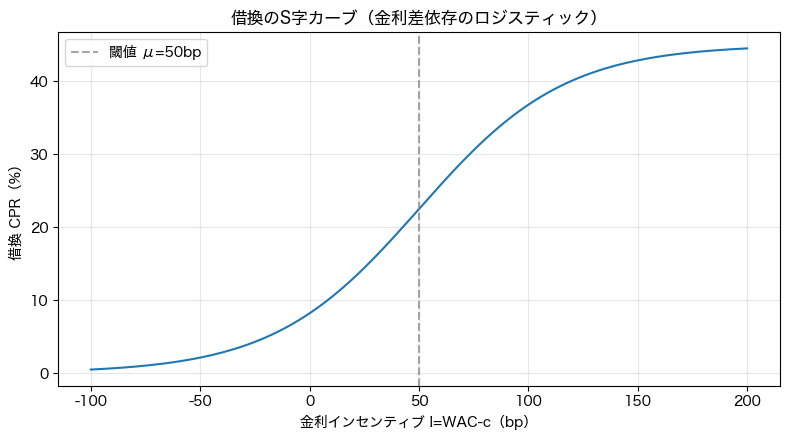

In [3]:
def logistic_refi_cpr(incentive, refi_max=0.45, beta=300.0, mu=0.005):
    """金利インセンティブ I=WAC-c に対する借換 CPR（S字カーブ）。"""
    incentive = np.asarray(incentive, dtype=float)
    return refi_max / (1.0 + np.exp(-beta * (incentive - mu)))


def statistical_mbs_cashflows(balance, wac, wam, market_rate,
                              turnover=0.06, refi_max=0.45, beta=300.0,
                              mu=0.005, gamma=2.0):
    """金利感応・バーンアウト込みの計量プリペイメントで月次CFを生成する（自作）。

    各月で CPR を「シーズニング×(底流 + 借換×バーンアウト)」として内生的に決め、
    残余元本へ SMM を適用する。返り値は my_mbs_cashflows に cpr/smm を加えた dict。
    """
    r = wac / 12.0
    incentive = wac - market_rate            # 金利インセンティブ（一定と仮定）
    bal = float(balance)
    orig = float(balance)
    cum_prepay = 0.0                         # 累積期限前償還額
    keys = ("month", "interest", "scheduled_principal", "prepayment",
            "total_principal", "cashflow", "balance", "cpr", "smm")
    rows = {k: [] for k in keys}
    for m in range(1, wam + 1):
        n_rem = wam - m + 1
        seasoning = min(1.0, m / 30.0)                       # PSA と同じランプ
        burnout = np.exp(-gamma * (cum_prepay / orig))       # 履歴依存の逓減
        refi = float(logistic_refi_cpr(incentive, refi_max, beta, mu)) * burnout
        cpr = seasoning * (turnover + refi)
        cpr = min(cpr, 0.60)                                 # 実務上の上限クリップ
        smm = 1.0 - (1.0 - cpr) ** (1.0 / 12.0)

        interest = bal * r
        pmt = bal * r / (1.0 - (1.0 + r) ** (-n_rem)) if bal > 0 else 0.0
        sched_prin = min(pmt - interest, bal)
        prepay = (bal - sched_prin) * smm
        total_prin = sched_prin + prepay
        cf = interest + total_prin
        bal -= total_prin
        cum_prepay += prepay
        for k, v in zip(keys, (m, interest, sched_prin, prepay, total_prin,
                               cf, bal, cpr, smm)):
            rows[k].append(v)
    return {k: np.array(v) for k, v in rows.items()}


# S字カーブの形を確認する。
inc_grid = np.linspace(-0.01, 0.02, 200)
refi_curve = logistic_refi_cpr(inc_grid)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(inc_grid * 1e4, refi_curve * 100, color="#1f77b4")
ax.axvline(0.005 * 1e4, ls="--", color="gray", alpha=0.7, label="閾値 μ=50bp")
ax.set_xlabel("金利インセンティブ I=WAC-c（bp）")
ax.set_ylabel("借換 CPR（%）")
ax.set_title("借換のS字カーブ（金利差依存のロジスティック）")
ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()

アウト・オブ・ザ・マネー（$I<0$）では借換 CPR は底に張り付き、閾値 $\mu$ 付近で急に
立ち上がり、ディープ・イン・ザ・マネー側で上限に頭打ちします。次にバーンアウトの効果を
見ます。同じ市場金利でも、期間が進むほど累積期限前償還が増えて借換反応（実現 CPR）が
逓減します。

findfont: Font family 'Yu Gothic' not found.


findfont: Font family 'Meiryo' not found.


findfont: Font family 'Noto Sans CJK JP' not found.


findfont: Font family 'Yu Gothic' not found.


findfont: Font family 'Meiryo' not found.


...

findfont: Font family 'Meiryo' not found.


findfont: Font family 'Noto Sans CJK JP' not found.


findfont: Font family 'Yu Gothic' not found.


findfont: Font family 'Meiryo' not found.


findfont: Font family 'Noto Sans CJK JP' not found.


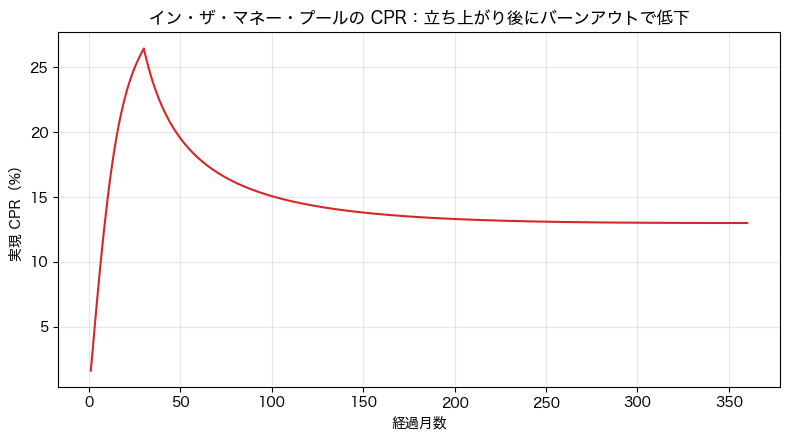

In [4]:
# 深くイン・ザ・マネー（市場金利がWACより150bp低い）の1本を走らせ、CPRの推移を見る。
wac_demo = 0.06
cf_itm = statistical_mbs_cashflows(100.0, wac_demo, 360, market_rate=wac_demo - 0.015)
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(cf_itm["month"], cf_itm["cpr"] * 100, color="#d62728")
ax.set_xlabel("経過月数")
ax.set_ylabel("実現 CPR（%）")
ax.set_title("イン・ザ・マネー・プールの CPR：立ち上がり後にバーンアウトで低下")
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()

立ち上がり（シーズニング）で CPR が上がったあと、期限前償還が累積するにつれ借換反応が
逓減し、CPR が緩やかに下がっていきます。金利は変えていないのに CPR が下がるのが
バーンアウトで、age だけの PSA では表せない履歴依存です。

## QuantLib検証

QuantLib には MBS/プリペイメントの評価器が実質的に無い（金利・信用の商品は充実するが、
期限前償還プールは対象外）ため、本 notebook では検証の柱を次の2本に置きます。

1. **自作 == bondlab**：`my_psa_cpr` / `my_cpr_to_smm` / `my_mbs_cashflows` /
   `my_wal` が `bondlab.mbs` と一致すること（上のスクラッチ節で確認済み）。
2. **PSA 検算**：PSA の定義（ランプ・倍率・CPR↔SMM 変換）を、実装に依らない独立式で
   再現し、`bondlab.mbs` の出力と突合すること。

「QuantLib で答え合わせ」に代わる位置づけとして、以下ではこの独立検算を行います。

In [5]:
# 検算1：PSA ramp は age30 で 6% ちょうど、以降フラット（PSA100）。
assert abs(psa_cpr(30, 100) - 0.06) < 1e-14
assert abs(psa_cpr(29, 100) - 0.06 * 29 / 30) < 1e-14   # ランプ上は 0.2%×age
assert abs(psa_cpr(31, 100) - 0.06) < 1e-14             # 30ヶ月以降は一定
assert abs(psa_cpr(15, 100) - 0.002 * 15) < 1e-14
print("PSA ramp 検算：age30 で CPR=6.00%、以降フラット、ランプ上は 0.2%×age")

# 検算2：PSA 倍率は CPR を一律スケール（クリップ後も倍率が効く）。
for psa in [50, 200, 400]:
    assert np.allclose(psa_cpr(ages, psa), psa_cpr(ages, 100) * (psa / 100.0), atol=1e-14)
print("PSA 倍率検算：PSA k は PSA100 の k/100 倍")

# 検算3：CPR↔SMM は独立式（対数経由）で往復一致。
cpr_ref = np.array([0.02, 0.06, 0.12, 0.24])
smm_indep = 1.0 - np.exp(np.log(1.0 - cpr_ref) / 12.0)   # = 1-(1-CPR)^(1/12)
assert np.allclose(cpr_to_smm(cpr_ref), smm_indep, atol=1e-15)
cpr_back = 1.0 - np.exp(12.0 * np.log(1.0 - smm_indep))
assert np.allclose(cpr_back, cpr_ref, atol=1e-12)
print("CPR↔SMM 検算：独立式（対数経由）と一致、往復も一致")

PSA ramp 検算：age30 で CPR=6.00%、以降フラット、ランプ上は 0.2%×age
PSA 倍率検算：PSA k は PSA100 の k/100 倍
CPR↔SMM 検算：独立式（対数経由）と一致、往復も一致


### PSA100/200/400 の CF と WAL 検算

PSA100/200/400 で月次キャッシュフローと WAL を、bondlab と「実装に依らない独立計算」の
2通りで求め、突合します。独立計算は残高を毎月自前で回し、予定元本・期限前償還・残高を
ループで積み上げるだけの素朴な実装です。

In [6]:
def independent_wal(balance, wac, wam, psa):
    """PSA 速度から、bondlab に依らずに残高を回して WAL を求める独立計算。"""
    r = wac / 12.0
    bal = balance
    num = 0.0   # Σ (月/12)×元本
    den = 0.0   # Σ 元本
    for m in range(1, wam + 1):
        n_rem = wam - m + 1
        cpr = min(0.06, 0.002 * m) * (psa / 100.0)     # PSA ランプ（独立式）
        smm = 1.0 - (1.0 - cpr) ** (1.0 / 12.0)
        interest = bal * r
        pmt = bal * r / (1.0 - (1.0 + r) ** (-n_rem))
        sched = min(pmt - interest, bal)
        prepay = (bal - sched) * smm
        prin = sched + prepay
        bal -= prin
        num += (m / 12.0) * prin
        den += prin
    return num / den


bal0, wac0, wam0 = 100.0, 0.055, 360
print(f"{'PSA':>6} {'独立WAL':>10} {'bondlab WAL':>12} {'総CF一致':>10}")
for psa in [100, 200, 400]:
    smm_path = cpr_to_smm(psa_cpr(np.arange(1, wam0 + 1), psa))
    cf = mbs_cashflows(bal0, wac0, wam0, smm_path)
    wal_bl = weighted_average_life(cf)
    wal_ind = independent_wal(bal0, wac0, wam0, psa)
    cf_match = np.isclose(cf["total_principal"].sum(), bal0, atol=1e-8)   # 元本は全額回収
    assert abs(wal_bl - wal_ind) < 1e-9
    print(f"{psa:>6} {wal_ind:>10.4f} {wal_bl:>12.4f} {str(bool(cf_match)):>10}")

print("\nPSA が速いほど WAL が短くなる（期限前償還が前倒しに元本を返す）")

   PSA      独立WAL  bondlab WAL      総CF一致
   100    11.2284      11.2284       True
   200     7.6072       7.6072       True
   400     4.5792       4.5792       True

PSA が速いほど WAL が短くなる（期限前償還が前倒しに元本を返す）


独立計算と bondlab の WAL が一致し、元本合計が初期残高に一致します（利息を除く元本は
期限前償還を含めて必ず全額返る）。PSA を上げると WAL が単調に短くなり、期限前償還が
キャッシュフローを前倒しにすることが数値で確認できます。

findfont: Font family 'Yu Gothic' not found.


findfont: Font family 'Meiryo' not found.


findfont: Font family 'Noto Sans CJK JP' not found.


findfont: Font family 'Yu Gothic' not found.


findfont: Font family 'Meiryo' not found.


...

findfont: Font family 'Meiryo' not found.


findfont: Font family 'Noto Sans CJK JP' not found.


findfont: Font family 'Yu Gothic' not found.


findfont: Font family 'Meiryo' not found.


findfont: Font family 'Noto Sans CJK JP' not found.


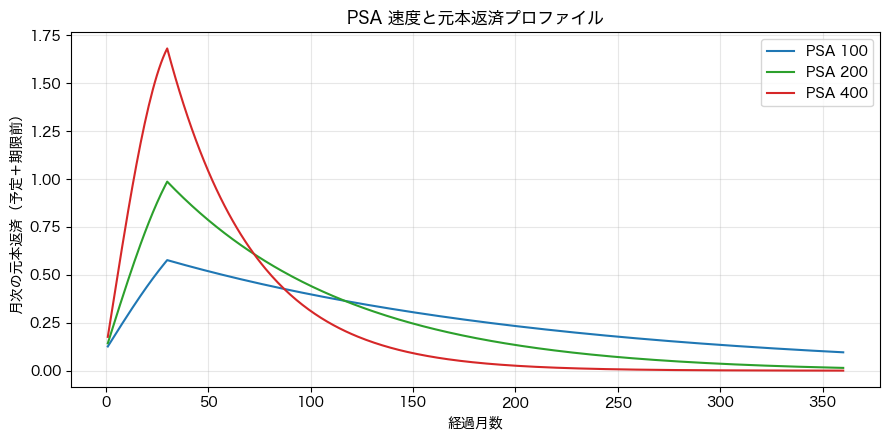

In [7]:
# PSA100/200/400 の月次元本（予定＋期限前）を可視化する。
fig, ax = plt.subplots(figsize=(9, 4.5))
colors = {"100": "#1f77b4", "200": "#2ca02c", "400": "#d62728"}
for psa in [100, 200, 400]:
    smm_path = cpr_to_smm(psa_cpr(np.arange(1, wam0 + 1), psa))
    cf = mbs_cashflows(bal0, wac0, wam0, smm_path)
    ax.plot(cf["month"], cf["total_principal"], color=colors[str(psa)],
            label=f"PSA {psa}")
ax.set_xlabel("経過月数")
ax.set_ylabel("月次の元本返済（予定＋期限前）")
ax.set_title("PSA 速度と元本返済プロファイル")
ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()

## 実データ適用

Fannie Mae 等の公開プールデータはユーザー登録が必要なため、ここでは現実的な WAC/WAM を
与えた合成プールを使います。30年ローン・WAC 5.5%・WAM 358 ヶ月（数ヶ月シーズン済み）で、
基準の市場住宅ローン金利を 5.5%（現行クーポン＝WAC、アット・ザ・マネー）に置きます。
割引には「国債＋MBSスプレッド（OAS）」に相当する年次パーカーブを `bootstrap_par` で
ブートストラップして使います。ここでテナーは**等間隔**（1年刻み）にします。`bootstrap_par`
は各テナーが連続する利払日という前提で残高を回すため、`[1,2,3,5,7,10,20,30]` のような
不等間隔を渡すと曲線が歪む（DF が過大になり価格が大きな premium に化ける）ためです。
割引利回りが WAC 近傍になるよう合わせるので、現行クーポン・プールは額面近辺で評価されます。
金利を $\pm$100bp 動かしたときの価格変化からネガティブコンベクシティを確認します。

In [8]:
# 合成プール諸元
POOL_BAL = 100.0
POOL_WAC = 0.055
POOL_WAM = 358
BASE_MKT_RATE = 0.055                              # 基準の市場住宅ローン金利（現行クーポン）
PAR_TENORS = np.arange(1.0, 31.0)                  # 等間隔の年次テナー（bootstrap_par の前提）
BASE_PAR = 0.052 + 0.0005 * np.log(PAR_TENORS)     # 割引利回り（国債＋OAS）。緩やかな順イールド


def mbs_price(rate_shift):
    """金利を rate_shift（小数）だけ平行移動したときの合成MBS価格とWAL。

    割引カーブと市場住宅ローン金利を同じだけシフトし、金利感応プリペイメントで
    キャッシュフローを再生成して現在価値を合計する。
    """
    disc = bootstrap_par(PAR_TENORS, BASE_PAR + rate_shift, frequency=1)
    cf = statistical_mbs_cashflows(POOL_BAL, POOL_WAC, POOL_WAM,
                                   market_rate=BASE_MKT_RATE + rate_shift)
    t_years = cf["month"] / 12.0
    price = float(np.sum(cf["cashflow"] * disc.discount(t_years)))
    wal = my_wal(cf)
    return price, wal, cf


# 基準・±100bp で価格と WAL を出す。
shifts = [-0.01, 0.0, 0.01]
labels = {-0.01: "-100bp", 0.0: "基準", 0.01: "+100bp"}
results = {}
print(f"{'シナリオ':>8} {'価格':>10} {'WAL(年)':>9} {'平均CPR':>9}")
for s in shifts:
    price, wal, cf = mbs_price(s)
    results[s] = price
    print(f"{labels[s]:>8} {price:>10.4f} {wal:>9.3f} {cf['cpr'].mean()*100:>8.2f}%")

    シナリオ         価格    WAL(年)     平均CPR
  -100bp   105.4262     5.098    13.82%
      基準   101.8896     8.432     8.35%
  +100bp    95.3846    10.941     5.96%


### ネガティブコンベクシティの確認

価格の金利に対する2階差分（コンベクシティの符号）を見ます。オプションを含まない普通の
債券なら $P(-\Delta)+P(+\Delta)-2P(0)>0$（正のコンベクシティ）ですが、MBS では金利低下時に
借換で期限前償還が加速して価格上昇が抑えられ（コンプレッション）、金利上昇時には期限前
償還が減ってデュレーションが伸び（エクステンション）価格が余計に下がるため、この2階差分が
負になります。

In [9]:
p_down, p_base, p_up = results[-0.01], results[0.0], results[0.01]
convexity_proxy = p_down + p_up - 2.0 * p_base
print(f"P(-100bp) = {p_down:.4f}")
print(f"P( 基準 ) = {p_base:.4f}")
print(f"P(+100bp) = {p_up:.4f}")
print(f"2階差分 P(-)+P(+)-2P(0) = {convexity_proxy:+.4f}  "
      f"→ {'負（ネガティブコンベクシティ）' if convexity_proxy < 0 else '正'}")

# 金利感応を無視した固定プリペイ（PSA 一定）MBS と比べる。
def mbs_price_fixed_psa(rate_shift, psa=160):
    """金利に反応しない固定PSAプリペイのMBS価格（比較用）。"""
    disc = bootstrap_par(PAR_TENORS, BASE_PAR + rate_shift, frequency=1)
    smm_path = cpr_to_smm(psa_cpr(np.arange(1, POOL_WAM + 1), psa))
    cf = mbs_cashflows(POOL_BAL, POOL_WAC, POOL_WAM, smm_path)
    t_years = cf["month"] / 12.0
    return float(np.sum(cf["cashflow"] * disc.discount(t_years)))


fx_down = mbs_price_fixed_psa(-0.01)
fx_base = mbs_price_fixed_psa(0.0)
fx_up = mbs_price_fixed_psa(0.01)
fx_conv = fx_down + fx_up - 2.0 * fx_base
print(f"\n固定PSA（金利非感応）の2階差分 = {fx_conv:+.4f}  "
      f"→ {'正（普通の債券的）' if fx_conv > 0 else '負'}")

assert convexity_proxy < 0        # 金利感応プリペイはネガティブコンベクシティ
assert fx_conv > convexity_proxy  # 金利非感応より必ずコンベクシティが悪い

P(-100bp) = 105.4262
P( 基準 ) = 101.8896
P(+100bp) = 95.3846
2階差分 P(-)+P(+)-2P(0) = -2.9685  → 負（ネガティブコンベクシティ）

固定PSA（金利非感応）の2階差分 = +0.6898  → 正（普通の債券的）


金利感応プリペイの MBS は2階差分が負（ネガティブコンベクシティ）、金利に反応しない固定
PSA の MBS は正になります。両者の差が、期限前償還オプションを借り手に渡していることの
対価です。価格を金利シフトの関数として描くと、MBS の価格曲線が上に凸（金利低下側で
頭打ち）になる様子が見えます。

findfont: Font family 'Yu Gothic' not found.


findfont: Font family 'Meiryo' not found.


findfont: Font family 'Noto Sans CJK JP' not found.


findfont: Font family 'Yu Gothic' not found.


findfont: Font family 'Meiryo' not found.


...

findfont: Font family 'Meiryo' not found.


findfont: Font family 'Noto Sans CJK JP' not found.


findfont: Font family 'Yu Gothic' not found.


findfont: Font family 'Meiryo' not found.


findfont: Font family 'Noto Sans CJK JP' not found.


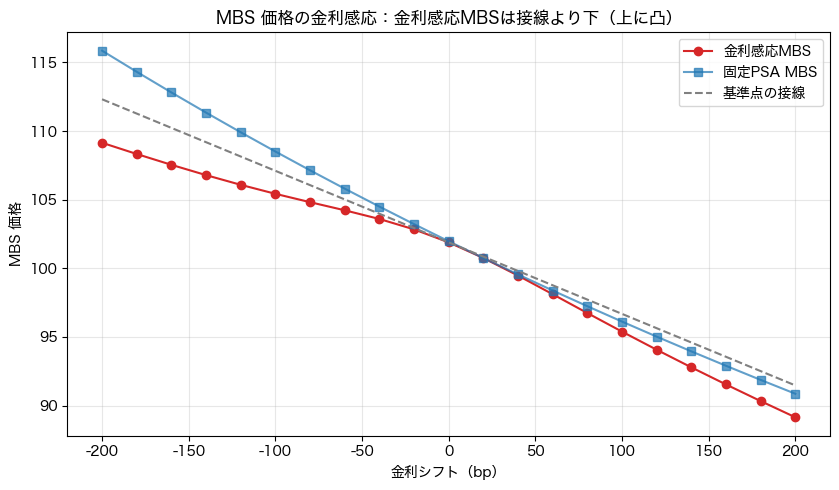

In [10]:
fine_shifts = np.linspace(-0.02, 0.02, 21)
prices_resp = np.array([mbs_price(s)[0] for s in fine_shifts])
prices_fixed = np.array([mbs_price_fixed_psa(s) for s in fine_shifts])

# 基準点での接線（1階微分）を中央差分で引き、凹凸を可視化する。
i0 = len(fine_shifts) // 2
slope = (prices_resp[i0 + 1] - prices_resp[i0 - 1]) / (fine_shifts[i0 + 1] - fine_shifts[i0 - 1])
tangent = prices_resp[i0] + slope * (fine_shifts - fine_shifts[i0])

fig, ax = plt.subplots(figsize=(8.5, 5))
ax.plot(fine_shifts * 1e4, prices_resp, "o-", color="#d62728", label="金利感応MBS")
ax.plot(fine_shifts * 1e4, prices_fixed, "s-", color="#1f77b4", alpha=0.7,
        label="固定PSA MBS")
ax.plot(fine_shifts * 1e4, tangent, "--", color="gray", label="基準点の接線")
ax.set_xlabel("金利シフト（bp）")
ax.set_ylabel("MBS 価格")
ax.set_title("MBS 価格の金利感応：金利感応MBSは接線より下（上に凸）")
ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()

金利感応 MBS の価格曲線は基準点の接線より下側に張り付き、金利低下側での値上がりが
抑えられます（上に凸＝ネガティブコンベクシティ）。固定 PSA の曲線は接線より上に膨らみ、
普通の債券と同じ正のコンベクシティを示します。

## 演習

1. **PSA 速度と WAL**：合成プール（残高100・WAC 5.5%・WAM 360）で、PSA を
   50, 100, 165, 250, 400, 600 と変えたときの WAL を `bondlab.mbs` で求め、
   表と折れ線にせよ。PSA を上げると WAL が単調に短くなること、短縮の逓減（速度を
   2倍にしても WAL は半分にならない）を数値で確認せよ。
2. **金利±100bp とネガティブコンベクシティ**：本文の金利感応プリペイモデルを使い、
   金利シフト $\{-100, -50, 0, +50, +100\}$ bp での MBS 価格を求めて、実効デュレーション
   と実効コンベクシティ
   $$
   D_{\text{eff}}=\frac{P_{-}-P_{+}}{2P_0\,\Delta}, \qquad
   C_{\text{eff}}=\frac{P_{-}+P_{+}-2P_0}{P_0\,\Delta^2}
   $$
   （$\Delta=0.01$）を計算せよ。$C_{\text{eff}}<0$ となること、同じプールを固定 PSA で
   評価すると $C_{\text{eff}}>0$ になることを比較して示せ。

解答例は `solutions/S8/sol_0801.py` に置く。

## 用語集

定義の正は `glossary/08_securitization.md`。ここでは初出語の一行要約のみ示す。

| 用語 | 英語 | 一行定義 |
|---|---|---|
| プリペイメント | prepayment | 住宅ローンの繰上返済。MBS の元本が予定より早く返る現象 |
| CPR | conditional prepayment rate | 期限前償還の年率。残高に対し1年で何%返るか |
| SMM | single monthly mortality | 期限前償還の月率。$1-\text{SMM}=(1-\text{CPR})^{1/12}$ |
| PSA | Public Securities Association model | age の関数で CPR を標準化した速度基準。100 で30ヶ月かけ6%へ |
| 加重平均年限 | weighted average life (WAL) | 元本返済を時点で加重した平均年限 |
| バーンアウト | burnout | 期限前償還を経たプールで、同じ金利差でも借換反応が鈍る履歴依存 |